Saving salary_lpa - Sheet1.csv to salary_lpa - Sheet1.csv
   Experience_years  Salary_lpa
0               0.5         3.0
1               1.0         3.5
2               2.0         4.5
3               3.0         5.2
4               4.0         6.0
Index(['Experience_years', 'Salary_lpa'], dtype='object')


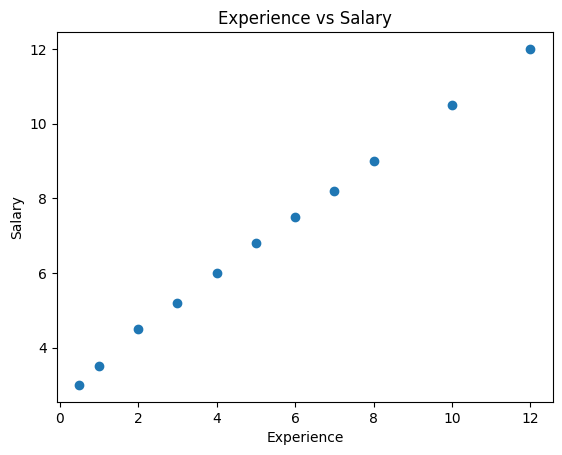

Salary = 0.76 * Experience + 2.89
Predicted Salary for 5 Years Experience: 6.7
MAE: 0.1275963718820862
MSE: 0.027804342326499632
R2 Score: 0.9970343792256637


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


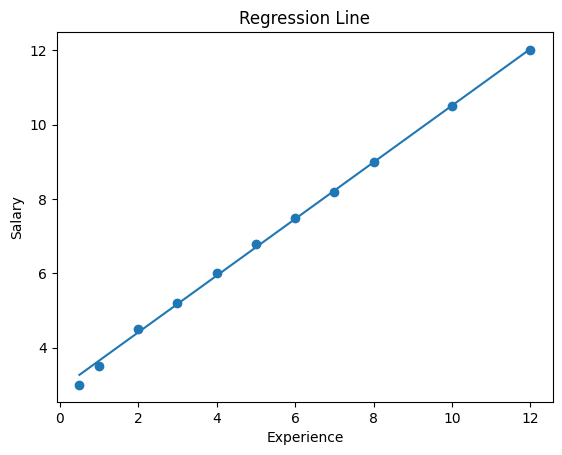

In [2]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

print(df.head())
print(df.columns)

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

plt.figure()
plt.scatter(X, y)
plt.xlabel("Experience")
plt.ylabel("Salary")
plt.title("Experience vs Salary")
plt.show()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

m = model.coef_[0]
b = model.intercept_

print("Salary =", round(m,2), "* Experience +", round(b,2))

y_pred = model.predict(X_test)

print("Predicted Salary for 5 Years Experience:", round(model.predict([[5]])[0],2))

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

plt.figure()
plt.scatter(X, y)
plt.plot(X, model.predict(X))
plt.xlabel("Experience")
plt.ylabel("Salary")
plt.title("Regression Line")
plt.show()